## Тестовый ноутбук для проверки библиотеки и данных по ионограммам

Ноутбук сделан для тестирования полученных данных

In [ ]:
# НЕ ставить pynasonde из PyPI: версия 0.0.2.4 устарела (нет пакета parsers, нет SBF).
# Используем копию GitHub main с патчами из ../pynasonde_git (скачать репозиторий).

import sys
import matplotlib.pyplot as plt

# тут надо вставить абсолютный путь
sys.path.insert(0, "........./pynasonde_git")
sys.path.insert(0, "........./modules")  # digi_formats.py

# --- для теста в папку положить НЕСКОЛЬКО файлов, по умолчанию возьмет все, но можно взять и прицельно один

path_to_sao = ".............../data/SBF-samples-w-img-n-sao/scaled"
DATA = ".............../data"

### Описание форматов (подробно — `data/format_description.md`)

- `RSF` (Routine Scientific Format): сырая ионограмма DPS-4D, бинарные блоки 4096 Б; на каждый бин дальности 2 байта — амплитуда (5 бит ×3 дБ), № доплеровской линии (3 бита), фаза (5 бит ×11.25°), азимут прихода (3 бита ×60°). O- и X-мода — отдельными группами. Jicamarca JI91J: 1–12 МГц/100 кГц, 80–1320 км/5 км.
- `SBF` (Single Byte Format): то же, но 1 байт на бин — только амплитуда + доплер, без направлений. Rome RO041: 1.5–15 МГц/50 кГц, 80–717.5 км/2.5 км.
- `SAO` (4.3): текст, результат автоскейлинга ARTIST — характеристики (foF2, hmF2, MUF3000, foE, foEs, B0, B1, TEC…), следы h′(f) по слоям и модам, профиль Ne(h) NHPC. Это же — «входные параметры» модели IRI.
- `EDP`: текстовый профиль Ne(h) с доверительными интервалами (утилита qualscan), сравнение ARTIST/POLAN.
- `DFT`: доплеровские спектры дрейфовых измерений (заголовок спрятан в младших битах амплитуд).
- `PNG`: официальные картинки Ion2PNG/DIAS — эталон для сверки.

In [13]:
import pandas as pd
import numpy as np

In [14]:
from pynasonde.digisonde.parsers.sao import SaoExtractor
from pynasonde.digisonde.parsers.rsf import RsfExtractor
from pynasonde.digisonde.parsers.sbf import SbfExtractor   # работает только с патчем в pynasonde_git (pip тут сломается)
from pynasonde.digisonde.parsers.edp import EdpExtractor
from pynasonde.digisonde.parsers.dft import DftExtractor
from pynasonde.digisonde.digi_plots import RsfIonogram, SaoSummaryPlots, SkySummaryPlots
import digi_formats as dfm   # самодельные парсеры (read_ionogram / read_sao / read_edp / read_dft)

In [ ]:


# --- не пугаться длинного логгера, корявость библиотеки, столько инфы не нужно
df = SaoExtractor.load_SAO_files(folders=[path_to_sao], func_name="height_profile", n_procs=4)
print(df.head())

2026-08-29 22:48:51.541 | INFO     | pynasonde.digisonde.digi_utils:collect_files:215 - Searching /Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms/data/SBF-samples-w-img-n-sao/scaled for ['*.SAO']: found 89 files
  0%|          | 0/89 [00:00<?, ?it/s]2026-08-29 22:48:53.568 | INFO     | pynasonde.vipir.ngi.utils:load_toml:198 - Loading from /Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms/pynasonde_git/pynasonde/config.toml
2026-08-29 22:48:53.568 | INFO     | pynasonde.vipir.ngi.utils:load_toml:198 - Loading from /Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms/pynasonde_git/pynasonde/config.toml
2026-08-29 22:48:53.568 | INFO     | pynasonde.vipir.ngi.utils:load_toml:198 - Loading from /Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms/pynasonde_git/pynasonde/config.toml
2026-08-29 22:48:53.568 | INFO     | pynasonde.vipir.ngi.utils:load_toml:198 - Loading from /Users/andreykhalov/HULK/P

        th     pf      ed   datetime      local_datetime   lat   lon  \
0   93.434  0.200   495.0 2022-01-01 2021-12-31 01:00:00  41.9  12.5   
1   95.000  0.236   689.0 2022-01-01 2021-12-31 01:00:00  41.9  12.5   
2  100.000  0.309  1180.0 2022-01-01 2021-12-31 01:00:00  41.9  12.5   
3  105.000  0.346  1480.0 2022-01-01 2021-12-31 01:00:00  41.9  12.5   
4  110.000  0.357  1580.0 2022-01-01 2021-12-31 01:00:00  41.9  12.5   

   record_index                                        source_file  
0             0  /Users/andreykhalov/HULK/PHD/conferences/2026/...  
1             0  /Users/andreykhalov/HULK/PHD/conferences/2026/...  
2             0  /Users/andreykhalov/HULK/PHD/conferences/2026/...  
3             0  /Users/andreykhalov/HULK/PHD/conferences/2026/...  
4             0  /Users/andreykhalov/HULK/PHD/conferences/2026/...  


2026-08-29 23:08:09.221 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:370 - Date: 2022-01-01 00:00:00
2026-08-29 23:08:09.223 | INFO     | pynasonde.digisonde.digi_utils:load_station_csv:532 - Loading from /Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms/pynasonde_git/pynasonde/digisonde_station_codes.csv
2026-08-29 23:08:09.584 | INFO     | pynasonde.vipir.ngi.utils:__init__:35 - Local Time: America/Lima
2026-08-29 23:08:09.590 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:394 - Station code: JI91J; {'ID': 55, 'URSI': 'JI91J', 'STATIONNAME': 'JICAMARCA', 'LAT': -12.0, 'LONG': -76.80000000000001}
2026-08-29 23:08:09.749 | INFO     | pynasonde.digisonde.parsers._rsf_sbf_base:to_pandas:225 - Extracted 54780 records from RSF file.
2026-08-29 23:08:10.359 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:370 - Date: 2022-01-01 00:00:00
2026-08-29 23:08:10.360 | INFO     | pynasonde.digisonde.digi_utils:l

RsfHeader(record_type=7, header_length=60, version_maker='0xfe', year=2022, doy=1, month=1, dom=1, hour=0, minute=0, second=0, stn_code_rx='012', stn_code_tx='012', schedule=6, program=2, start_frequency=1000000.0, coarse_frequency_step=100000.0, stop_frequency=12000000.0, fine_frequency_step=0.0, num_small_steps_in_scan=1, phase_code=1, option_code=7, number_of_samples=3, pulse_repetition_rate=100.0, range_start=80.0, range_increment=5, number_of_heights=256.0, delay=0.0, base_gain=0, frequency_search=2, operating_mode=0, data_format=4, printer_output=0, threshold=nan, constant_gain=0, cit_length=15104, journal=6, bottom_height_window=90.0, top_height_window=640.0, number_of_heights_stored=8.0, spare=b'\x14\x00', number_of_frequency_groups=8)
(54780, 55) (138240, 54)


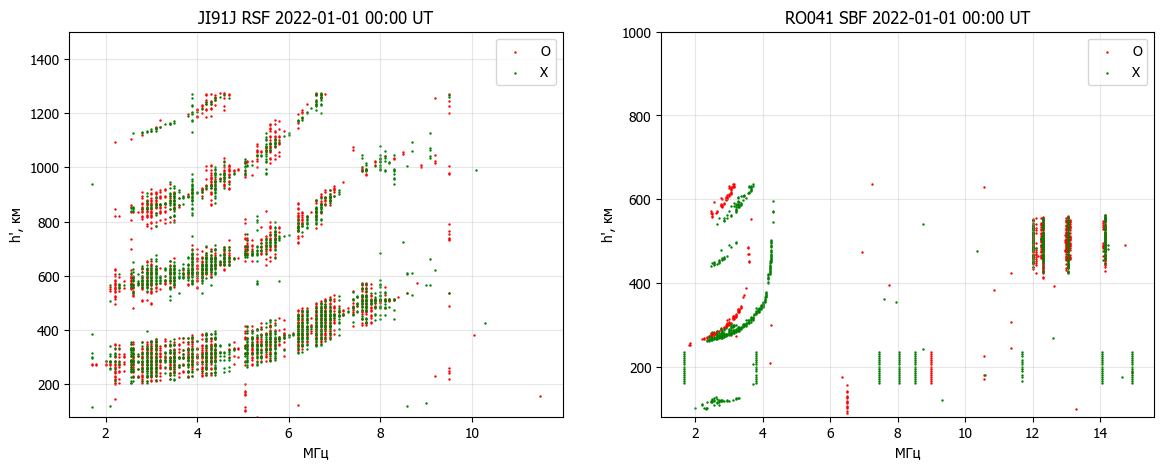

2026-08-29 23:08:12.884 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:370 - Date: 2022-01-01 00:00:00
2026-08-29 23:08:12.884 | INFO     | pynasonde.digisonde.digi_utils:load_station_csv:532 - Loading from /Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms/pynasonde_git/pynasonde/digisonde_station_codes.csv
2026-08-29 23:08:13.245 | INFO     | pynasonde.vipir.ngi.utils:__init__:35 - Local Time: America/Lima
2026-08-29 23:08:13.251 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:394 - Station code: JI91J; {'ID': 55, 'URSI': 'JI91J', 'STATIONNAME': 'JICAMARCA', 'LAT': -12.0, 'LONG': -76.80000000000001}


,B0,B1,D,D1,Ht,M3000F,MUF3000,TEC,dfoF,downF,...,hmE,hmF2,ymE,ymF2,datetime,local_datetime,lat,lon,record_index,source_file
0,136.0,1.16,3000.0,0.0,54.615,2.676,21.941,19.632,0.0,0.0,...,110.0,369.9,20.0,114.377,2022-01-01,2021-12-31 19:00:00,-12.0,-76.8,0,/Users/andreykhalov/HULK/PHD/conferences/2026/...


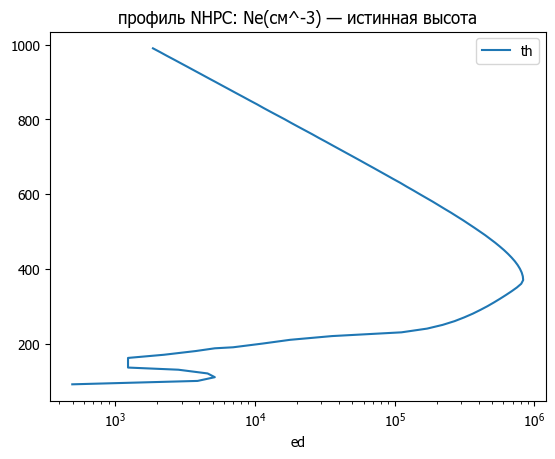

In [36]:
# читаем сырые форматы (без интерпритации, это наши данные для разметки)

# --- сырая ионограмма RSF и SBF через pynasonde 
# --- очень длинный logger, опять, но он сильно глубоко зашит в библиотеку
rsf = RsfExtractor(f"{DATA}/RSF-samples-w-img-n-sao-n-dft/ionogram/JI91J_2022001000000.RSF", True, True); rsf.extract()
df_rsf = rsf.to_pandas()
sbf = SbfExtractor(f"{DATA}/SBF-samples-w-img-n-sao/ionogram/RO041_2022001000000.SBF", True, True); sbf.extract()
df_sbf = sbf.to_pandas()
print(rsf.rsf_data.rsf_data_units[0].header)
print(df_rsf.shape, df_sbf.shape)

# порог по шуму (MPA — most probable amplitude группы) — иначе рисуется сплошной шум
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, ttl, hmax in [(axes[0], df_rsf, "JI91J RSF", 1500), (axes[1], df_sbf, "RO041 SBF", 1000)]:
    e = df[df.amplitude > df.mpa + 6]
    for pol, c in [("O", "r"), ("X", "g")]:
        s = e[e.pol == pol]; ax.scatter(s.frequency_reading / 1e6, s.height, s=3, c=c, label=pol, linewidths=0)
    ax.set_ylim(80, hmax); ax.set_xlabel("МГц"); ax.set_ylabel("h', км"); ax.set_title(f"{ttl} 2022-01-01 00:00 UT"); ax.legend(); ax.grid(alpha=.3)
plt.show()

# --- SAO: характеристики одной ионограммы
sao = SaoExtractor(f"{DATA}/RSF-samples-w-img-n-sao-n-dft/scaled/JI91J_2022001000000.SAO", True, True); sao.extract()
display(sao.get_scaled_datasets().dropna(axis=1))
sao.get_height_profile().plot(x="ed", y="th", logx=True, title="профиль NHPC: Ne(см^-3) — истинная высота"); plt.show()

## Отчёт "как у дигизонда" (Ion2PNG): эхо + следы ARTIST + профиль NHPC + таблица характеристик

Что на картинке:
- **точки** — эхо выше шума (амплитуда > MPA + 6 дБ, фильтрация): O-мода красным, X-мода зелёным;
- **цветные линии** — следы, которые ARTIST выделил и записал в SAO (группы 7–33): полилинии *h′(f)* по узлам сетки прибора;
- **чёрная линия** — профиль NHPC: плазменная частота = **истинная** высота (группы 51–52 SAO). Он рисуется в той же плоскости, потому что ось X у ионограммы — частота, а плазменная частота на высоте h — это та частота, которая от этой высоты отражается; поэтому профиль лежит *левее и ниже* O-следа (истинная высота < действующей), а его вершина hmF2 — над асимптотой foF2;
- **левая колонка** — характеристики из SAO в порядке Ion2PNG, C-level (группа 5, поз. 10: 11 — лучший, 55 — худший) и версия ARTIST;
- **таблица MUF(D)** внизу — наша оценка по закону секанса для зеркала на h′ над сферической Землёй (`ion_report.muf_secant`); ARTIST считает MUF по истинному профилю (трассировка), поэтому его MUF(3000) выше нашей на прим 10 %.

Функции — в `data/ion_report.py`.

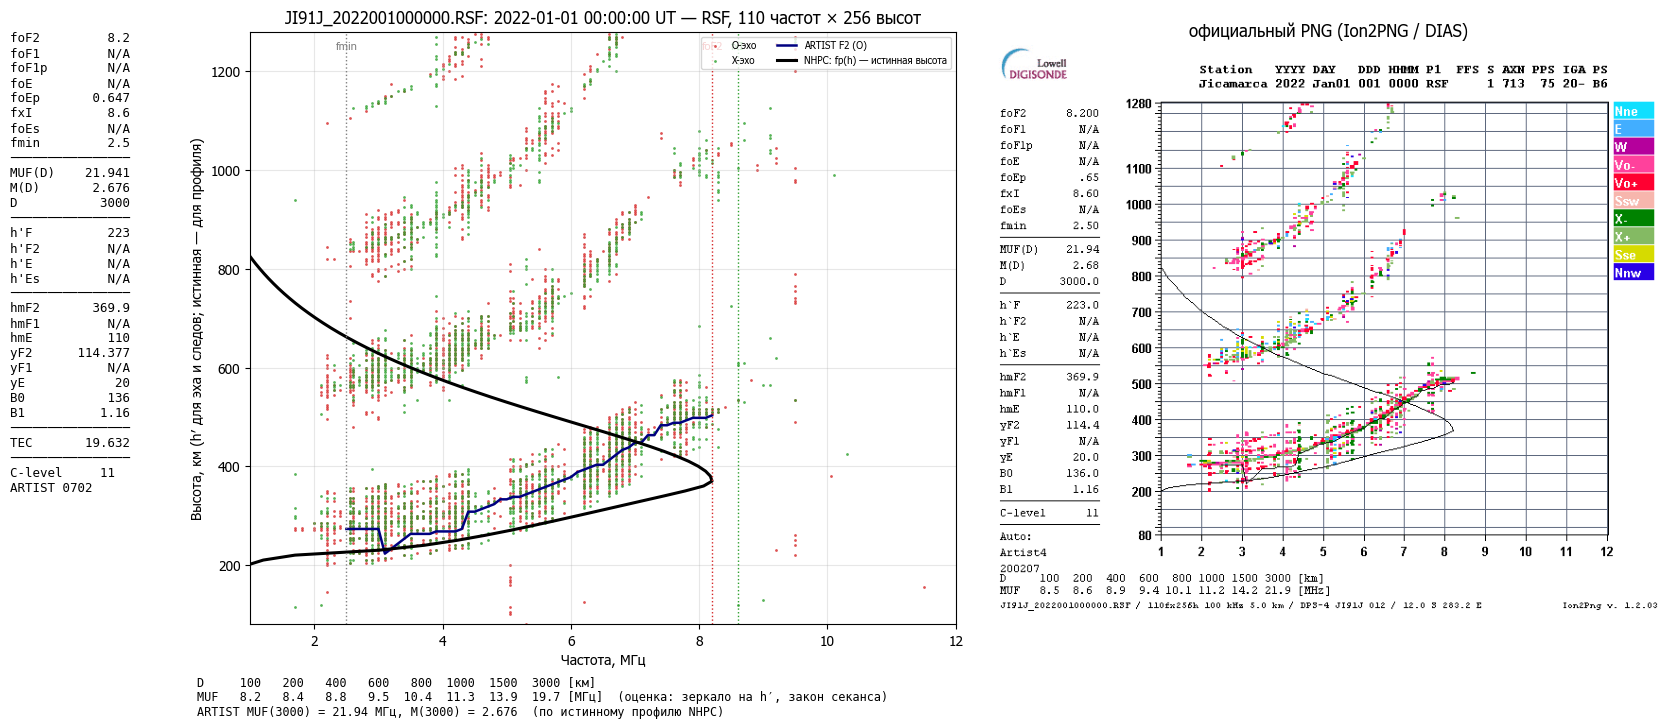

наша MUF(D) по закону секанса: {100: 8.2, 200: 8.4, 400: 8.8, 600: 9.5, 800: 10.4, 1000: 11.3, 1500: 13.9, 3000: 19.7}


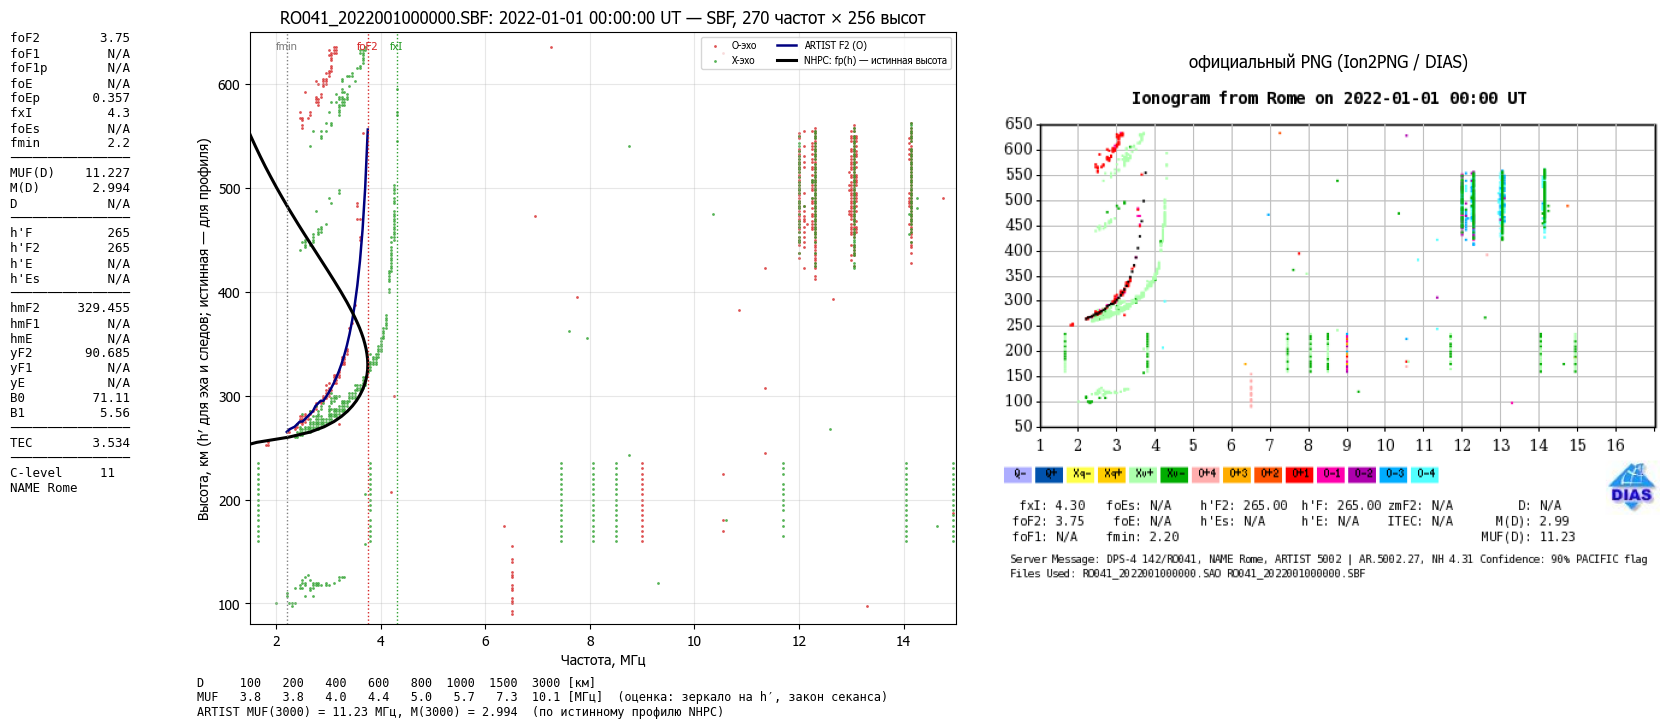

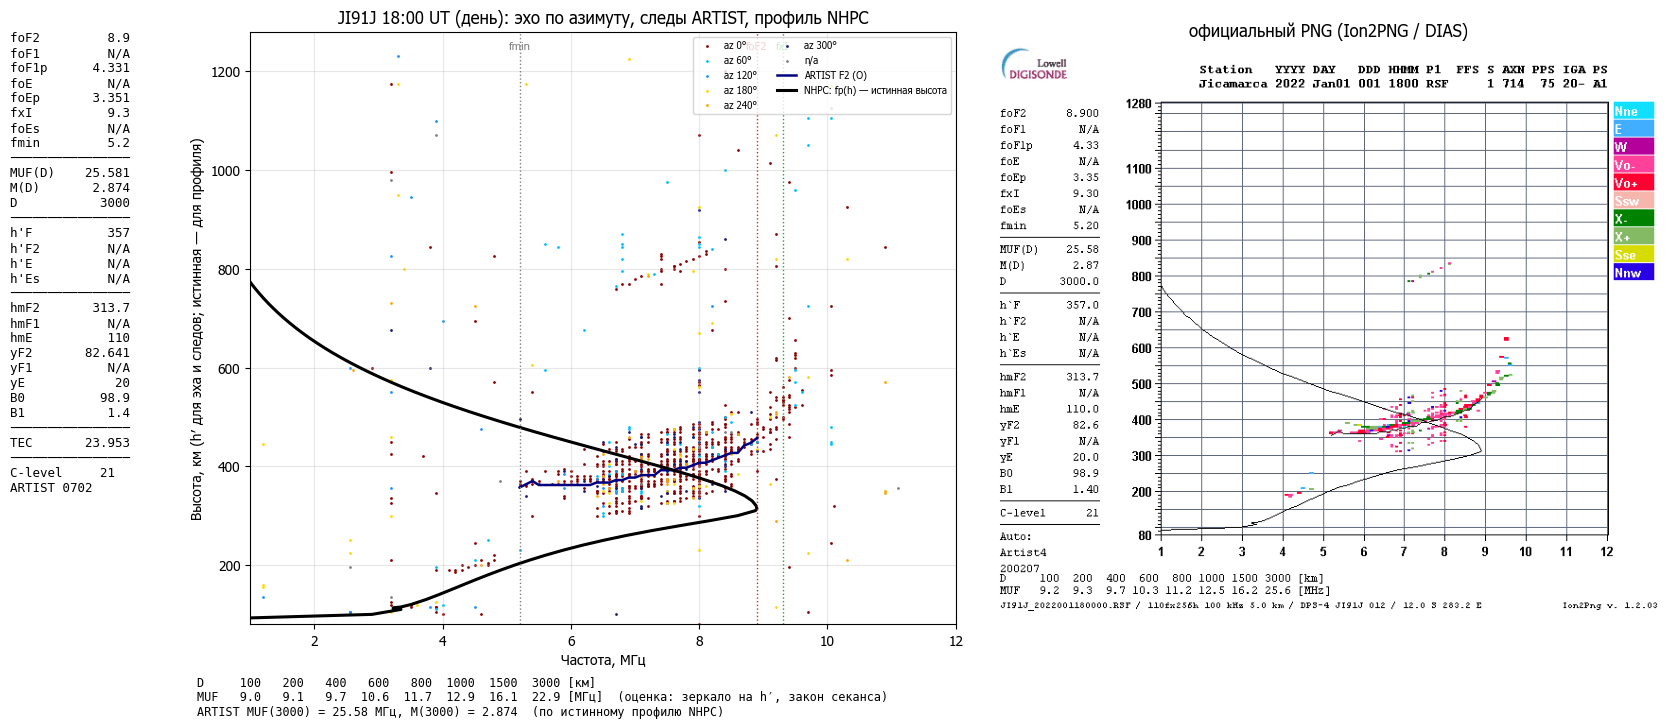

In [39]:
import ion_report as ir
R = f"{DATA}/RSF-samples-w-img-n-sao-n-dft"; S = f"{DATA}/SBF-samples-w-img-n-sao"

# Jicamarca 00:00 UT (RSF) — наш отчёт рядом с официальным PNG
fig, info = ir.digisonde_report(f"{R}/ionogram/JI91J_2022001000000.RSF", f"{R}/scaled/JI91J_2022001000000.SAO",
                                f"{R}/image/JI91J_2022001000000_IO.PNG", fmax=12, hmax=1280)
plt.show()
print("наша MUF(D) по закону секанса:", {d: round(v, 1) for d, v in info["muf_secant"].items()})

# Rome 00:00 UT (SBF)
fig, info = ir.digisonde_report(f"{S}/ionogram/RO041_2022001000000.SBF", f"{S}/scaled/RO041_2022001000000.SAO",
                                f"{S}/image/RO041_2022001000000_IO.PNG", fmax=15, hmax=650)
plt.show()

# RSF позволяет раскрасить эхо по азимуту прихода (как легенда Nne/E/W/… на PNG): show_azimuth=True
fig, _ = ir.digisonde_report(f"{R}/ionogram/JI91J_2022001180000.RSF", f"{R}/scaled/JI91J_2022001180000.SAO",
                             f"{R}/image/JI91J_2022001180000_IO.PNG", fmax=12, hmax=1280, show_azimuth=True,
                             title="JI91J 18:00 UT (день): эхо по азимуту, следы ARTIST, профиль NHPC")
plt.show()

2026-08-29 22:35:31.621 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:370 - Date: 2022-01-01 00:00:00
2026-08-29 22:35:31.622 | INFO     | pynasonde.digisonde.digi_utils:load_station_csv:532 - Loading from /Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms/pynasonde_git/pynasonde/digisonde_station_codes.csv
2026-08-29 22:35:31.984 | INFO     | pynasonde.vipir.ngi.utils:__init__:35 - Local Time: America/Lima
2026-08-29 22:35:31.988 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:394 - Station code: JI91J; {'ID': 55, 'URSI': 'JI91J', 'STATIONNAME': 'JICAMARCA', 'LAT': -12.0, 'LONG': -76.80000000000001}


,digi_formats,pynasonde,PNG (Ion2PNG),Δ pyn−ours
foF2,8.200,8.200,8.20,0.0
M3000F2,2.676,2.676,2.68,0.0
MUF3000F2,21.941,21.941,21.94,0.0
fmin,2.500,2.500,2.50,0.0
fxI,8.600,8.600,8.60,0.0
hF,223.000,223.000,223.00,0.0
zmE,110.000,110.000,110.00,0.0
yE,20.000,20.000,20.00,0.0
D,3000.000,3000.000,3000.00,0.0
fMUF,8.200,8.200,NaN,0.0


2026-08-29 22:35:31.999 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:370 - Date: 2022-01-01 00:00:00
2026-08-29 22:35:31.999 | INFO     | pynasonde.digisonde.digi_utils:load_station_csv:532 - Loading from /Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms/pynasonde_git/pynasonde/digisonde_station_codes.csv


максимальное расхождение pynasonde − digi_formats: 0.0


2026-08-29 22:35:32.335 | INFO     | pynasonde.vipir.ngi.utils:__init__:35 - Local Time: America/Lima
2026-08-29 22:35:32.339 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:394 - Station code: JI91J; {'ID': 55, 'URSI': 'JI91J', 'STATIONNAME': 'JICAMARCA', 'LAT': -12.0, 'LONG': -76.80000000000001}
2026-08-29 22:35:32.358 | INFO     | pynasonde.digisonde.digi_utils:setsize:129 - scienceplots available: unknown
2026-08-29 22:35:32.358 | INFO     | pynasonde.digisonde.digi_utils:setsize:129 - scienceplots available: unknown


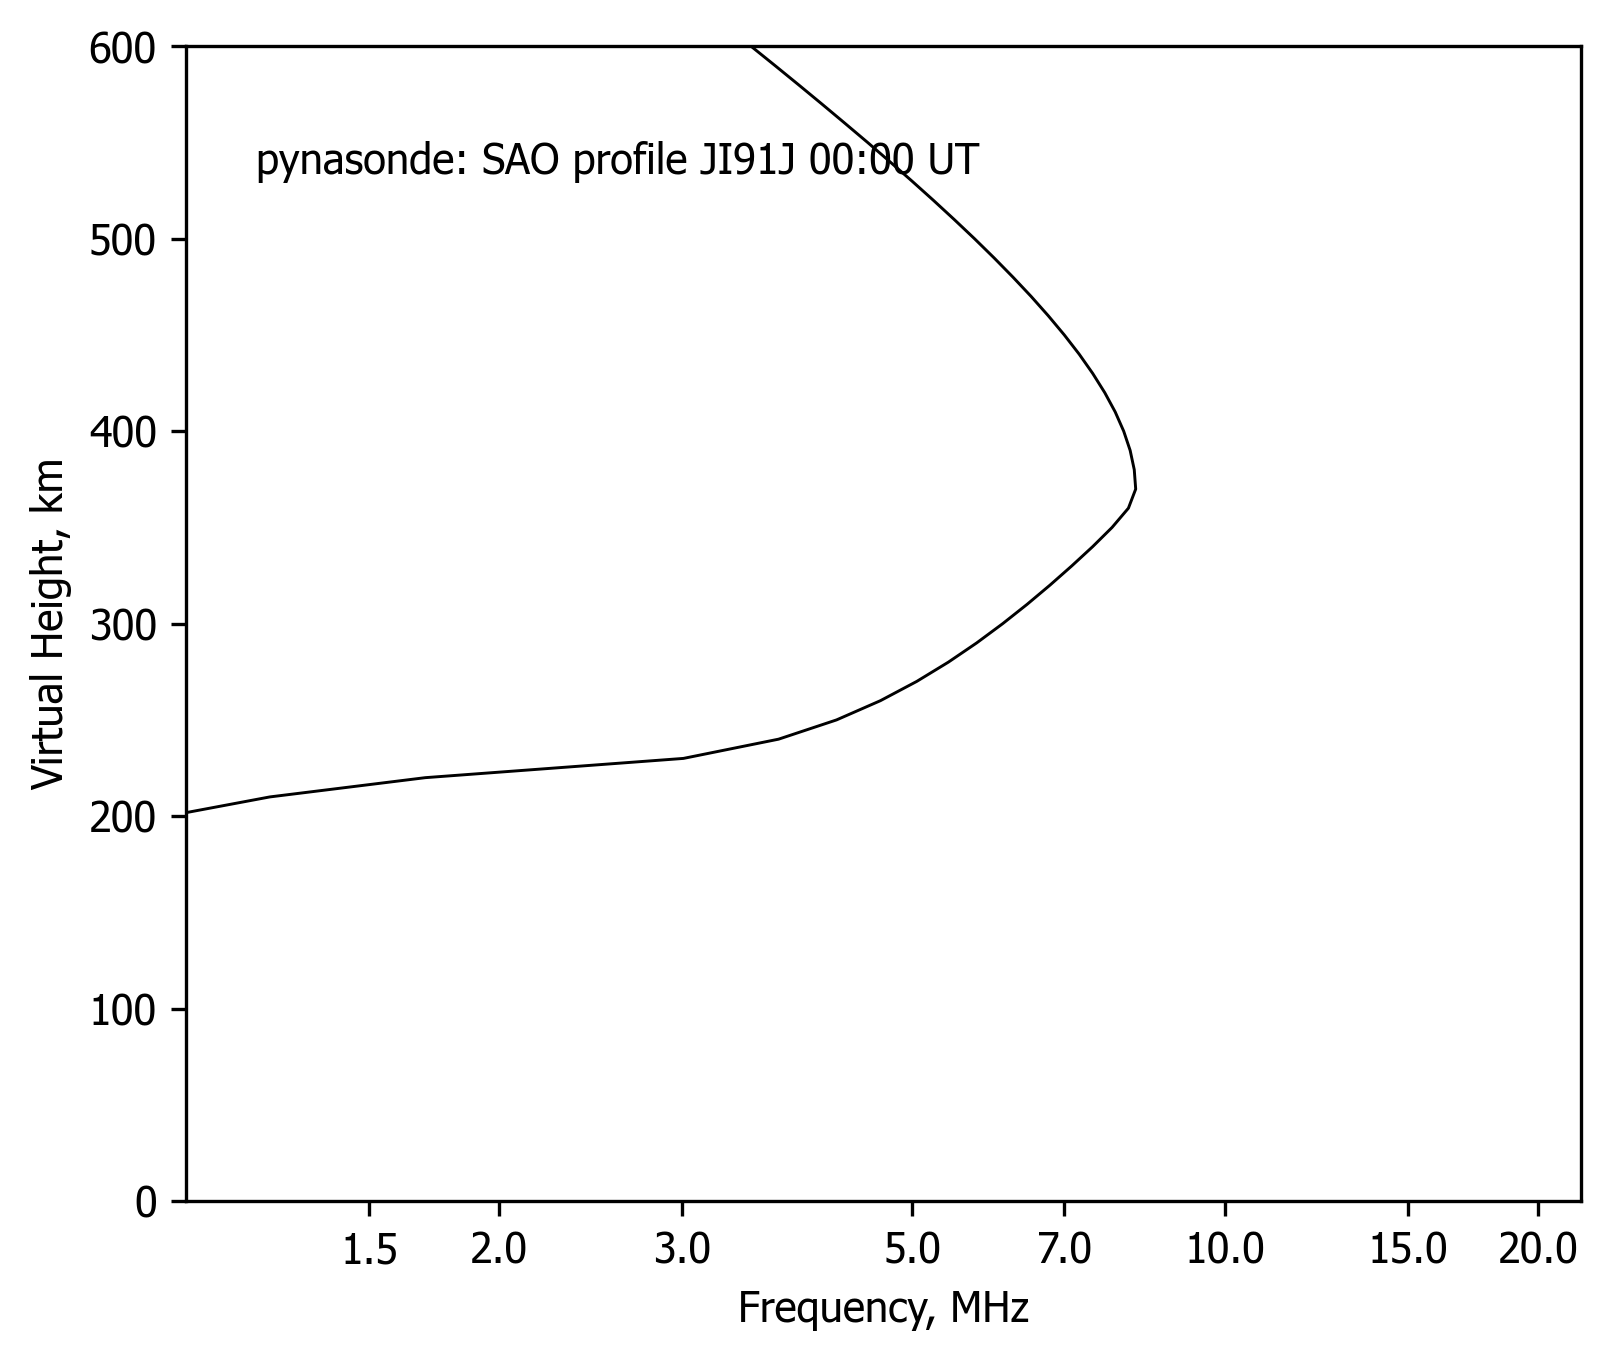

2026-08-29 22:35:32.444 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:370 - Date: 2022-01-01 00:00:00
2026-08-29 22:35:32.445 | INFO     | pynasonde.digisonde.digi_utils:load_station_csv:532 - Loading from /Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms/pynasonde_git/pynasonde/digisonde_station_codes.csv
2026-08-29 22:35:33.135 | INFO     | pynasonde.vipir.ngi.utils:__init__:35 - Local Time: America/Lima
2026-08-29 22:35:33.142 | INFO     | pynasonde.digisonde.digi_utils:apply_filename_metadata:394 - Station code: JI91J; {'ID': 55, 'URSI': 'JI91J', 'STATIONNAME': 'JICAMARCA', 'LAT': -12.0, 'LONG': -76.80000000000001}
2026-08-29 22:35:33.285 | INFO     | pynasonde.digisonde.parsers._rsf_sbf_base:to_pandas:225 - Extracted 54780 records from RSF file.
2026-08-29 22:35:33.921 | INFO     | pynasonde.digisonde.digi_utils:setsize:129 - scienceplots available: unknown
2026-08-29 22:35:33.921 | INFO     | pynasonde.digisonde.digi_utils:setsize:129

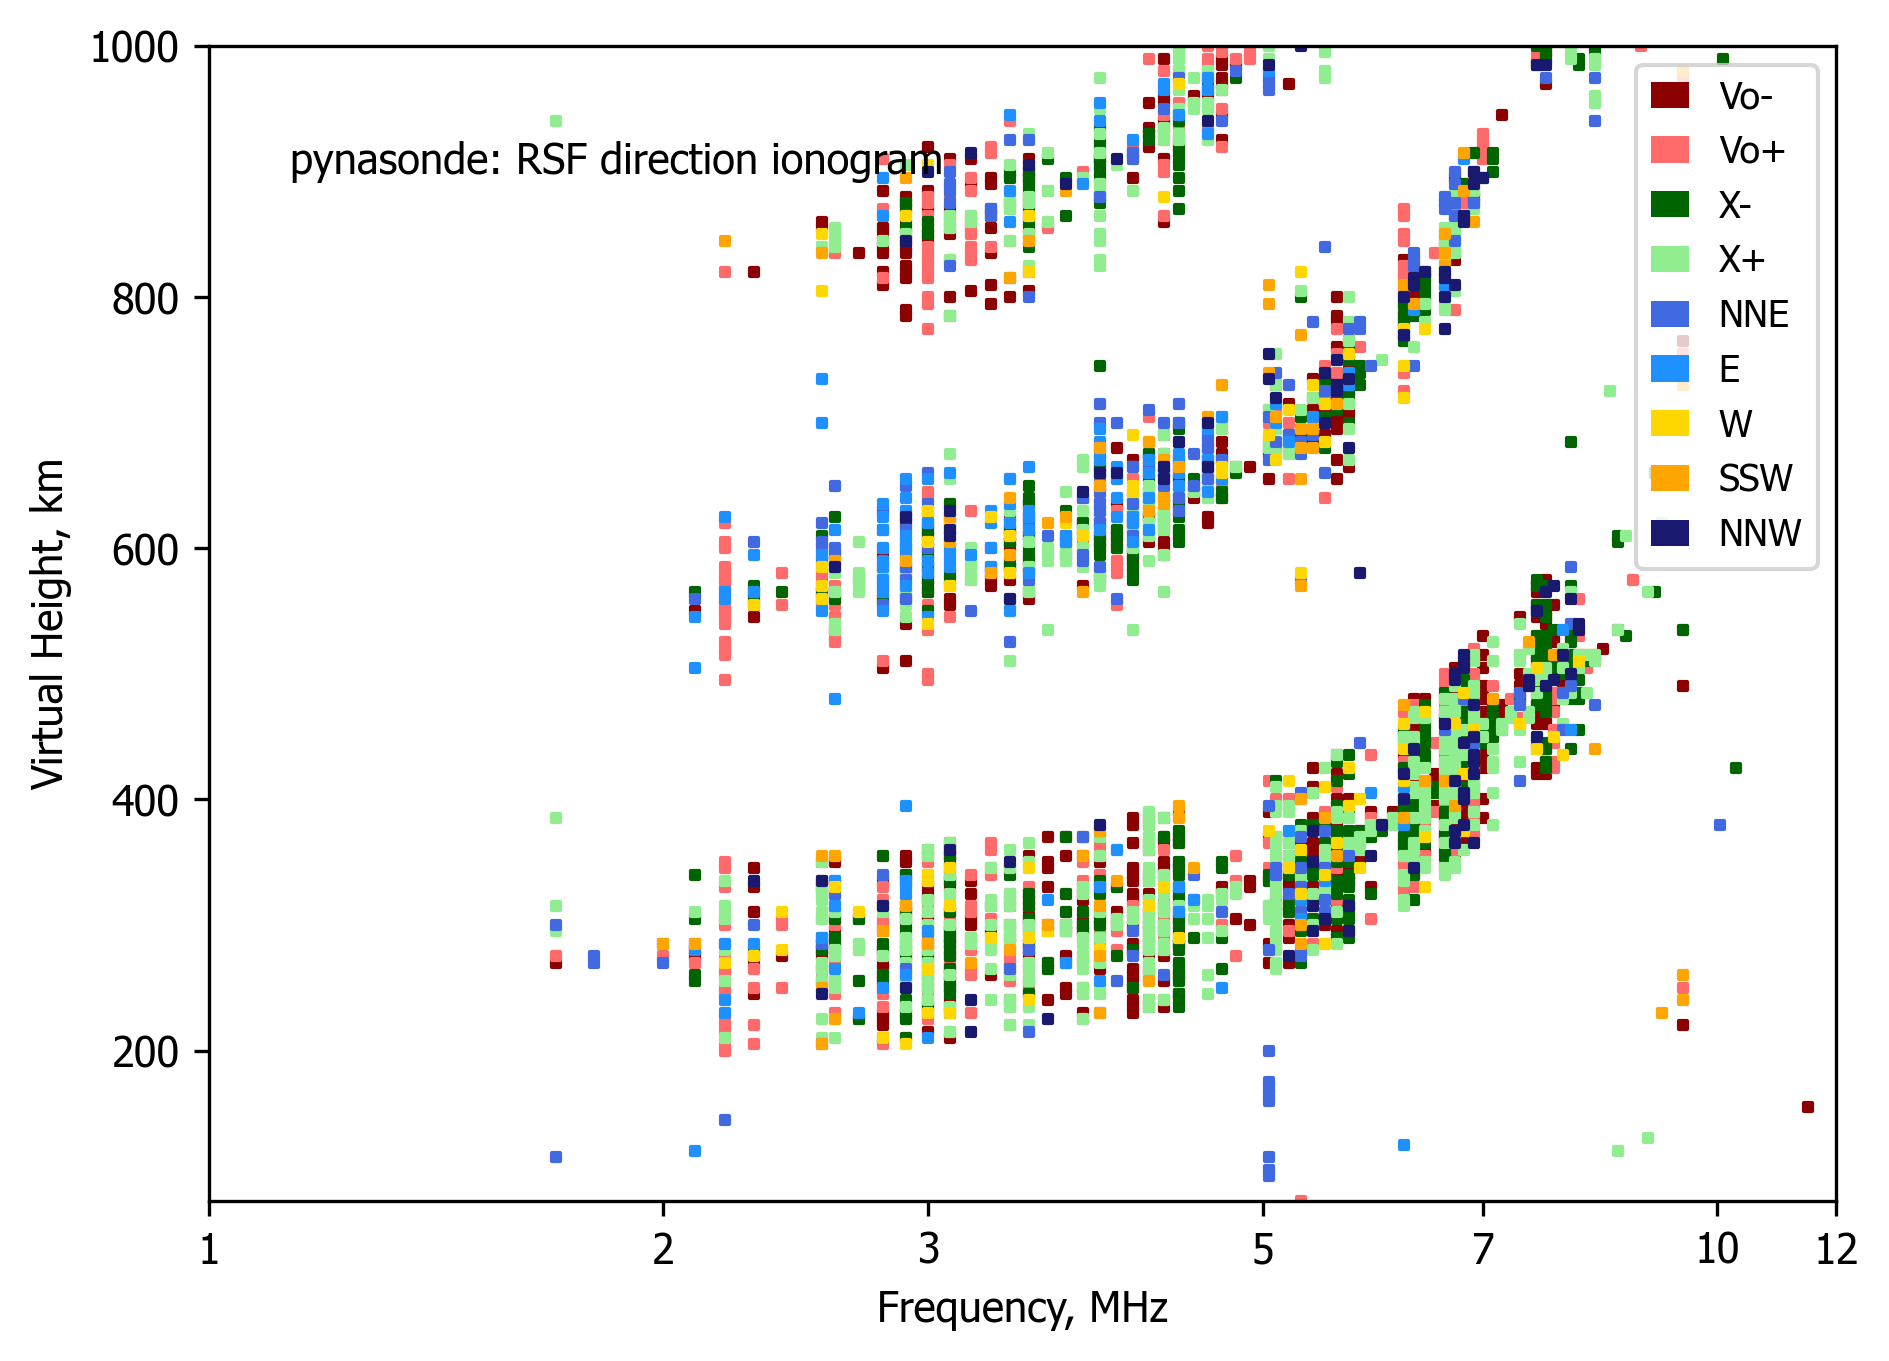

In [7]:
# 1) три чтения одного SAO: наш парсер, pynasonde, значения с PNG (прочитаны с JI91J_2022001000000_IO.PNG)
tab = ir.compare_sao_parsers(f"{R}/scaled/JI91J_2022001000000.SAO", ir.PNG_VALUES_JI91J_000000)
display(tab.dropna(how="all", subset=["digi_formats", "pynasonde", "PNG (Ion2PNG)"]))
print("максимальное расхождение pynasonde − digi_formats:", np.nanmax(np.abs(tab["Δ pyn−ours"])))

# 2) рендер pynasonde для той же ионограммы: профиль NHPC (plot_ionogram) и эхо RSF по направлениям
sao = SaoExtractor(f"{R}/scaled/JI91J_2022001000000.SAO", True, True); sao.extract()
prof = sao.get_height_profile()
p = SaoSummaryPlots(figsize=(6, 5), font_size=10)
p.plot_ionogram(prof, text="pynasonde: SAO profile JI91J 00:00 UT")   # fp(h) по профилю NHPC
plt.show()

rsf = RsfExtractor(f"{R}/ionogram/JI91J_2022001000000.RSF", True, True); rsf.extract()
d = rsf.to_pandas(); d = d[d.amplitude > d.mpa + 6]           # без порога по MPA рисуется сплошной шум
r = RsfIonogram(figsize=(7, 5), font_size=10)
r.add_direction_ionogram(d, ylim=[80, 1000], xlim=[1, 12], xticks=[1, 2, 3, 5, 7, 10, 12],
                         text="pynasonde: RSF direction ionogram", lower_plimit=5, ms=3)
plt.show()

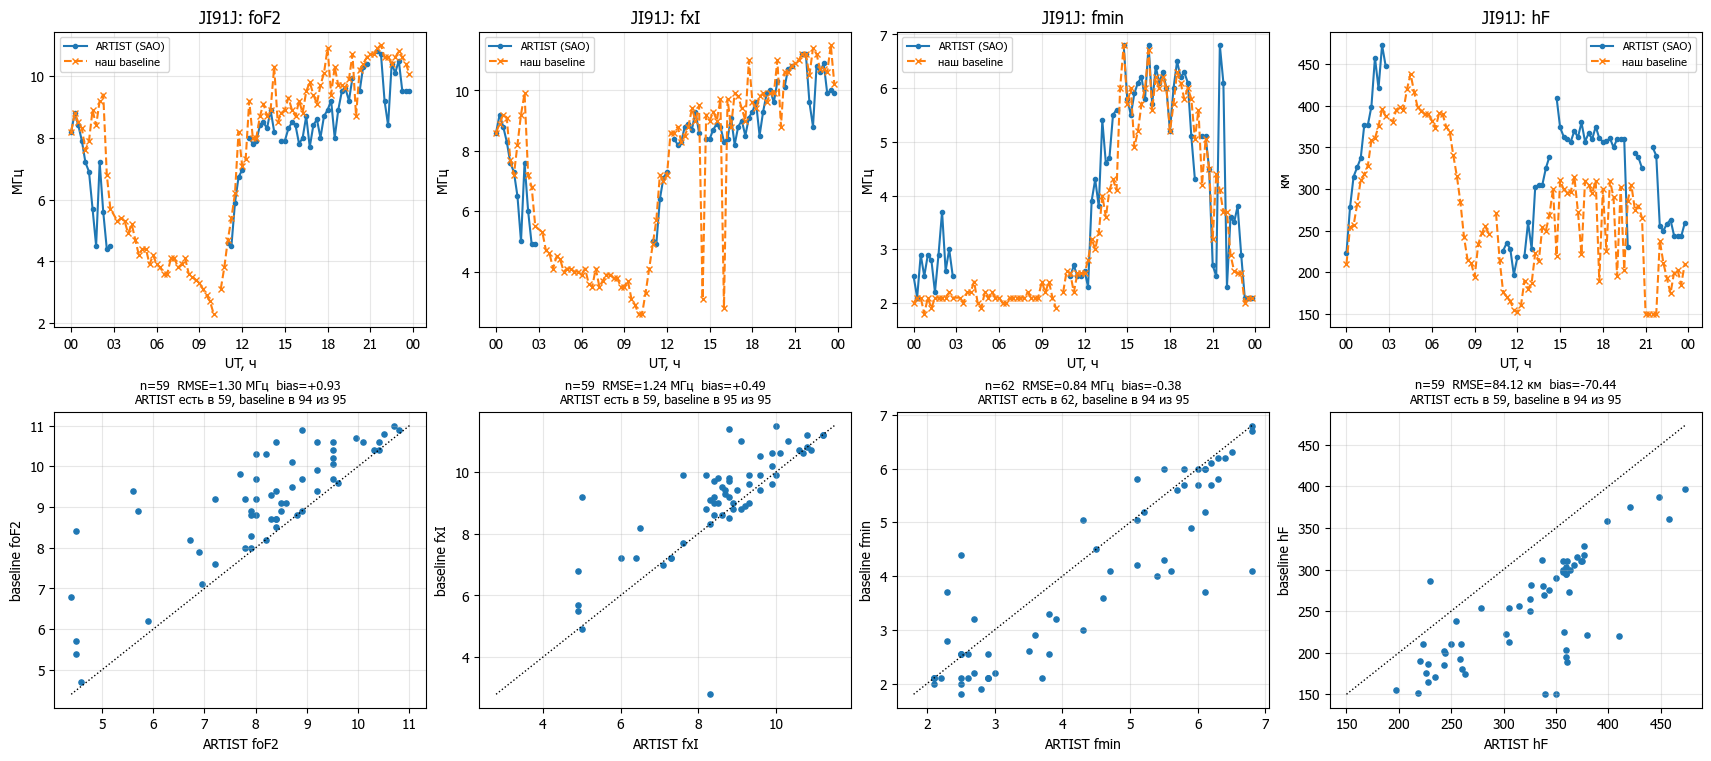

JI91J: ARTIST выдал foF2 в 59 из 95 ионограмм; наш baseline — в 94


,time,fmin_base,hF_base,foF2_base,fxI_base,fmin_artist,hF_artist,foF2_artist,fxI_artist,c_level
0,2022-01-01 00:00:00,2.0,210.0,8.2,8.6,2.5,223.0,8.2,8.6,11
1,2022-01-01 00:15:00,2.1,254.0,8.8,8.9,2.1,278.0,8.8,9.2,11
2,2022-01-01 00:30:00,2.1,256.5,8.5,9.2,2.9,315.0,8.4,8.8,11
3,2022-01-01 00:45:00,1.8,281.5,8.3,9.1,2.5,326.0,7.9,8.3,11
4,2022-01-01 01:00:00,2.1,311.0,7.6,7.7,2.9,337.0,7.2,7.6,11
5,2022-01-01 01:15:00,1.9,317.5,7.9,7.2,2.8,377.0,6.9,7.3,11
6,2022-01-01 01:30:00,2.1,328.0,8.9,8.2,2.2,377.0,5.7,6.5,11
7,2022-01-01 01:45:00,2.1,358.5,8.4,9.2,2.9,399.0,4.5,5.0,11


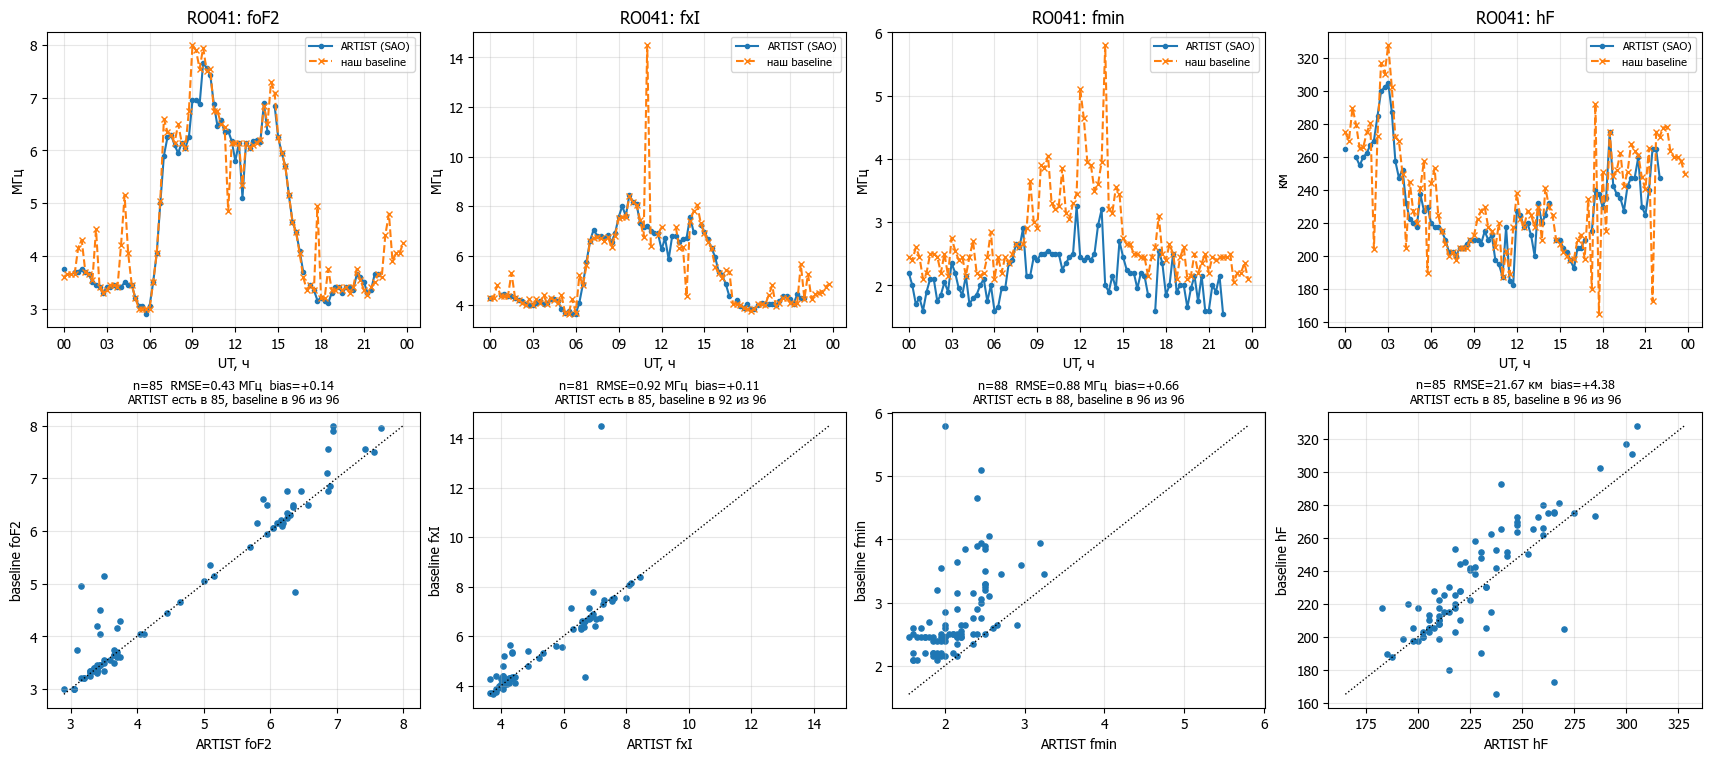

RO041: ARTIST выдал foF2 в 85 из 96 ионограмм; наш baseline — в 96


,time,fmin_base,hF_base,foF2_base,fxI_base,fmin_artist,hF_artist,foF2_artist,fxI_artist,c_level
0,2022-01-01 00:00:00,2.45,275.00,3.60,4.30,2.2,265.0,3.75,4.30,11
1,2022-01-01 00:15:00,2.40,270.00,3.65,4.30,2.0,NaN,NaN,NaN,44
2,2022-01-01 00:30:00,2.60,290.00,3.65,4.80,1.7,NaN,NaN,NaN,44
3,2022-01-01 00:45:00,2.45,279.75,3.65,4.35,1.8,260.0,3.70,4.40,11
4,2022-01-01 01:00:00,2.10,265.50,4.15,4.35,1.6,255.0,3.70,4.45,11
5,2022-01-01 01:15:00,2.20,266.00,4.30,4.35,1.9,260.0,3.75,4.35,11
6,2022-01-01 01:30:00,2.50,275.00,3.70,5.30,2.1,262.5,3.70,4.35,11
7,2022-01-01 01:45:00,2.50,280.75,3.65,4.30,2.1,267.5,3.65,4.30,22


In [8]:
# 3) наш наивный автоскейлер vs ARTIST за сутки (все 95 RSF Jicamarca и 96 SBF Rome; ~1 мин)
for st, d, ext in [("JI91J", R, "RSF"), ("RO041", S, "SBF")]:
    tb = ir.baseline_vs_artist(f"{d}/ionogram", f"{d}/scaled", ext)
    fig = ir.plot_baseline_vs_artist(tb, st); plt.show()
    print(f"{st}: ARTIST выдал foF2 в {tb.foF2_artist.notna().sum()} из {len(tb)} ионограмм; наш baseline — в {tb.foF2_base.notna().sum()}")
    display(tb.head(8))

# Что видно (см. также data/format_description.md, §I.4.1):
# - Rome (чистая среднеширотная ионосфера): даже наивная эвристика даёт foF2 с RMSE ≈ 0.4 МГц от ARTIST —
#   основная трудность здесь не «найти след», а fmin/h'F (помехи-столбцы, слабое начало следа) и X-мода;
# - Jicamarca ночью: ARTIST молчит 03–11 UT (spread-F, C-level 55), а baseline выдаёт числа —
#   но они ничем не подтверждены; кратники 2F/3F и наклонные эхо эвристика не отличает от основного следа.
# Это и есть исходная точка для задачи обучения: разметка ARTIST — учитель, физические ограничения (V1–V7) — фильтр.

## pynasonde vs ARTIST: что можно сравнивать, а что нет

Важно: **pynasonde не автоскейлер** — для дигизонда у неё нет своего ARTIST-подобного алгоритма (есть только `vipir.ngi.scale.AutoScaler` для ионозонда VIPIR). Она *читает* SAO и рисует. Поэтому сравнить можно три вещи:

1. **Парсеры SAO**: `digi_formats.read_sao` = `pynasonde SaoExtractor` = числа с официального PNG (Ion2PNG). Картинки совпадают, SAO читаем правильно.
2. **Рендер pynasonde** (`SaoSummaryPlots.plot_ionogram` рисует профиль NHPC как «ионограмму», `RsfIonogram.add_direction_ionogram` — эхо по направлениям) = наш отчёт = PNG.
3. **Наш собственный наивный автоскейлер** (`ion_report.baseline_scale`: порог MPA+6 дБ, непрерывный O-след -> fmin/foF2/h′F, X-след -> fxI) <-> ARTIST за все сутки. Это и есть ответ «сходятся или нет» и стартовая точка для задачи обучения: насколько далеко простая эвристика от ARTIST, насколько далеко модельный вывод от ARTIST.

Что дальше: построить модельное представление ARTIST, обучение с учителем - размеченные автоскейлером ионограммы ВЗ с дигизонда, здесь же отсев физически невозможных автоскейлов (модель учится на RL сигнале от графа знаний)

Цель: проверить будет ли сигнал с символьного слоя выравнивать модель на ARTIST